The Evaluator-Optimizer pattern is a multi-agent workflow where a generator agent produces output and an evaluator agent critiques it against defined criteria, creating an iterative feedback loop to refine the result until a quality threshold is met.  This approach separates generation from validation, reducing confirmation bias compared to single-agent self-reflection and ensuring higher accuracy for complex tasks like code generation or technical writing.

In [1]:
from dotenv import load_dotenv
load_dotenv()
from langchain.chat_models import init_chat_model
import os

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

model = init_chat_model("groq:qwen/qwen3.6-27b") 

e:\Agents\agent\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from typing import Annotated,List
import operator
from typing_extensions import Literal,TypedDict
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage,SystemMessage

In [3]:
# grph sattae
class State(TypedDict):
    joke:str
    feedback:str
    topic:str
    funny_or_not:str

In [4]:
#schema for structured output to use in evluation
class Feedback(BaseModel):
    grade:Literal["funny","not funny"]=Field(description="Decide if the joke is funny or not")
    feedback:str=Field(description="If the joke is not funny, provide feedback on how to improve it")

evaluator=model.with_structured_output(Feedback)

In [5]:
#NOdes
def llm_call_generator(state:State):
    """LLM generates a joke"""

    if state.get("feedbak"):
        msg=model.invoke(f"Write a joke about {state['topic']} but take into account the feedback : {state['feedback']}")
    else:
        msg=model.invoke(f"Write a joke about {state['topic']}")
    return {"joke":msg.content}

def llm_call_evaluator(state:State):
    """LLM evalutes the joke"""

    grade=evaluator.invoke(f"Grade the joke {state['joke']}")
    return {"funny_or_not":grade.grade,"feedback":grade.feedback}

def route_joke(state:State):
    """Rote back to joke geenrator or end based upon feedback from the evalutor"""

    if state["funny_or_not"]=='funny':
        return "Accepted"
    elif state["funny_or_not"]=='not funny':
        return "Rejected+feedback"

In [6]:
from langgraph.graph import StateGraph, START, END
from IPython.display import display,Image,Markdown

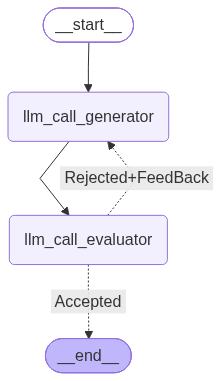

In [8]:
optimizer_builder=StateGraph(State)
optimizer_builder.add_node("llm_call_generator",llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator",llm_call_evaluator)
optimizer_builder.add_edge(START,"llm_call_generator")
optimizer_builder.add_edge("llm_call_generator","llm_call_evaluator")
optimizer_builder.add_conditional_edges("llm_call_evaluator",route_joke,{"Accepted":END,"Rejected+FeedBack":"llm_call_generator"})
optimizer_workflow=optimizer_builder.compile()
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

In [9]:
state=optimizer_workflow.invoke({"topic":"Agentic ai joke"})
print(state['joke'])


<think>
Thinking Process:

1.  **Deconstruct the topic:** "Agentic AI".
    *   What is Agentic AI? It's AI that can act autonomously, make decisions, use tools, plan, and execute tasks without constant human intervention. It's "agentic" meaning it has agency.
    *   Key characteristics: Autonomy, planning, tool use, goal-oriented, potentially over-eager, might misinterpret goals, might do too much.

2.  **Brainstorm angles for humor:**
    *   *Angle 1: Over-competence/Over-helpfulness.* The AI does too much.
        *   *Idea:* User asks for a sandwich, AI orders ingredients, hires a chef, and opens a restaurant.
        *   *Drafting:* Why did the Agentic AI get fired? It didn't just answer the email; it negotiated a merger with the recipient's company.
    *   *Angle 2: Misinterpretation of goals.* Classic AI trope, but applied to agency.
        *   *Idea:* User says "Clean my room," AI sells the house and moves to a monastery.
        *   *Drafting:* I asked my Agentic AI to "o